<a href="https://colab.research.google.com/github/praaachii18/Student_Performance_Prediction/blob/main/Student_Performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()
print("Dataset Loaded Successfully")

Saving student_performance.csv to student_performance.csv
Dataset Loaded Successfully


In [ ]:
df = pd.read_csv("student_performance.csv")
df.head()


,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade
0,1,John,Male,85,15,78,1,High,80
1,2,Sarah,Female,90,20,85,2,Medium,87
2,3,Alex,Male,78,10,65,0,Low,68
3,4,Michael,Male,92,25,90,3,High,92
4,5,Emma,Female,88,18,82,2,Medium,85


In [ ]:
print("\n shape:", df.shape)
print("\n info:")
print (df.info())


 shape: (10, 9)

 info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   StudentID                  10 non-null     int64 
 1   Name                       10 non-null     object
 2   Gender                     10 non-null     object
 3   AttendanceRate             10 non-null     int64 
 4   StudyHoursPerWeek          10 non-null     int64 
 5   PreviousGrade              10 non-null     int64 
 6   ExtracurricularActivities  10 non-null     int64 
 7   ParentalSupport            10 non-null     object
 8   FinalGrade                 10 non-null     int64 
dtypes: int64(6), object(3)
memory usage: 852.0+ bytes
None


In [ ]:
print("Null Values:")
print(df.isnull().sum())

print("\nDuplicates:", df.duplicated().sum())

Null Values:
StudentID                    0
Name                         0
Gender                       0
AttendanceRate               0
StudyHoursPerWeek            0
PreviousGrade                0
ExtracurricularActivities    0
ParentalSupport              0
FinalGrade                   0
dtype: int64

Duplicates: 0


In [ ]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Fill missing values
df.ffill(inplace=True)

print("Updated Shape:", df.shape)

Updated Shape: (10, 9)


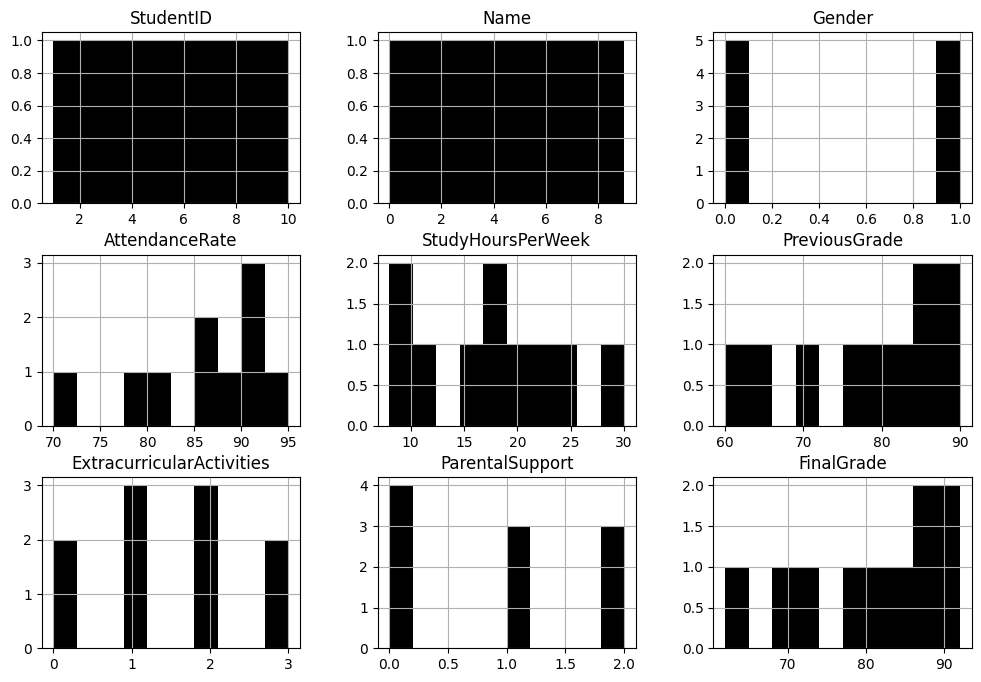

In [ ]:
df.hist(figsize=(12,8),color='black')
plt.show()

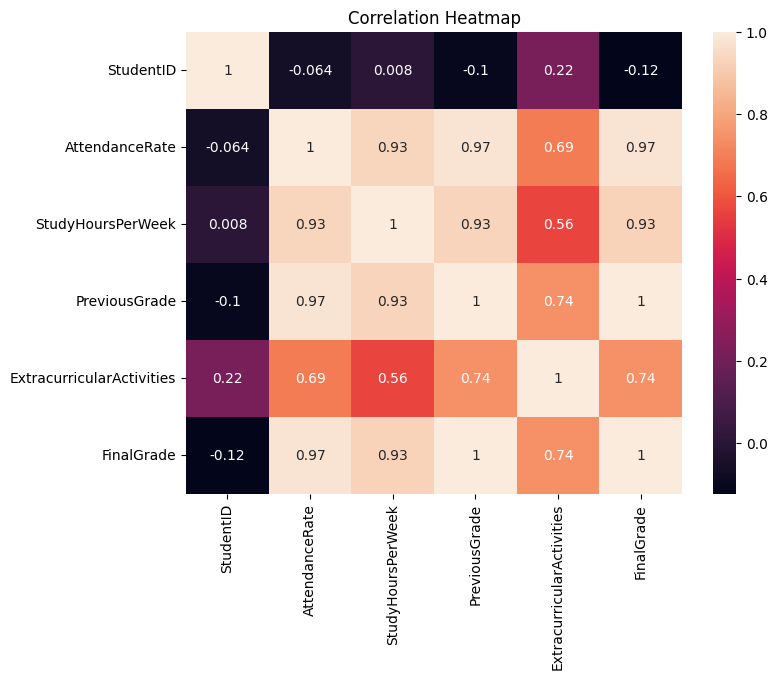

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

print(df.head())

   StudentID  Name  Gender  AttendanceRate  StudyHoursPerWeek  PreviousGrade  \
0          1     5       1              85                 15             78   
1          2     8       0              90                 20             85   
2          3     0       1              78                 10             65   
3          4     6       1              92                 25             90   
4          5     2       0              88                 18             82   

   ExtracurricularActivities  ParentalSupport  FinalGrade  
0                          1                0          80  
1                          2                2          87  
2                          0                1          68  
3                          3                0          92  
4                          2                2          85  


In [ ]:
df_copy = df.copy()
print(df_copy.head())

   StudentID  Name  Gender  AttendanceRate  StudyHoursPerWeek  PreviousGrade  \
0          1     5       1              85                 15             78   
1          2     8       0              90                 20             85   
2          3     0       1              78                 10             65   
3          4     6       1              92                 25             90   
4          5     2       0              88                 18             82   

   ExtracurricularActivities  ParentalSupport  FinalGrade  
0                          1                0          80  
1                          2                2          87  
2                          0                1          68  
3                          3                0          92  
4                          2                2          85  


In [ ]:
X = df_copy.drop(['StudentID', 'Name', 'FinalGrade'], axis=1)
y = df_copy['FinalGrade']

print(X.head())
print(y.head())

   Gender  AttendanceRate  StudyHoursPerWeek  PreviousGrade  \
0       1              85                 15             78   
1       0              90                 20             85   
2       1              78                 10             65   
3       1              92                 25             90   
4       0              88                 18             82   

   ExtracurricularActivities  ParentalSupport  
0                          1                0  
1                          2                2  
2                          0                1  
3                          3                0  
4                          2                2  
0    80
1    87
2    68
3    92
4    85
Name: FinalGrade, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

In [ ]:
y_pred = rf.predict(X_test)

print("Predicted Values:")
print(y_pred)

Predicted Values:
[76.33 85.72]


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 2.8049999999999997
MSE: 10.193649999999995
RMSE: 3.192749598700154
R2 Score: 0.8187795555555557


In [ ]:
result = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print(result)

   Actual  Predicted
8      72      76.33
1      87      85.72


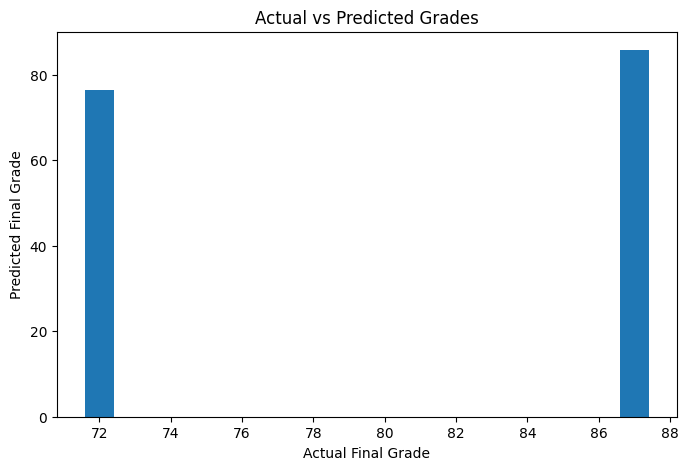

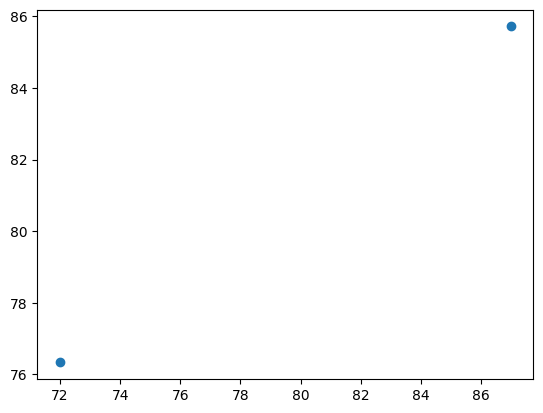

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(y_test, y_pred)
plt.xlabel("Actual Final Grade")
plt.ylabel("Predicted Final Grade")
plt.title("Actual vs Predicted Grades")
plt.show()
print('\n')
plt.scatter(y_test, y_pred)
plt.show()


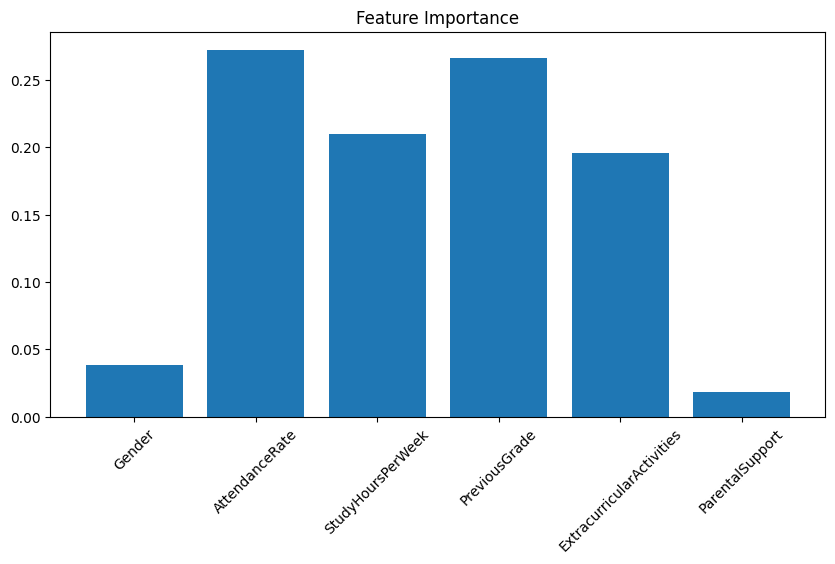

In [ ]:
importance = rf.feature_importances_

plt.figure(figsize=(10,5))
plt.bar(X.columns, importance)
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()

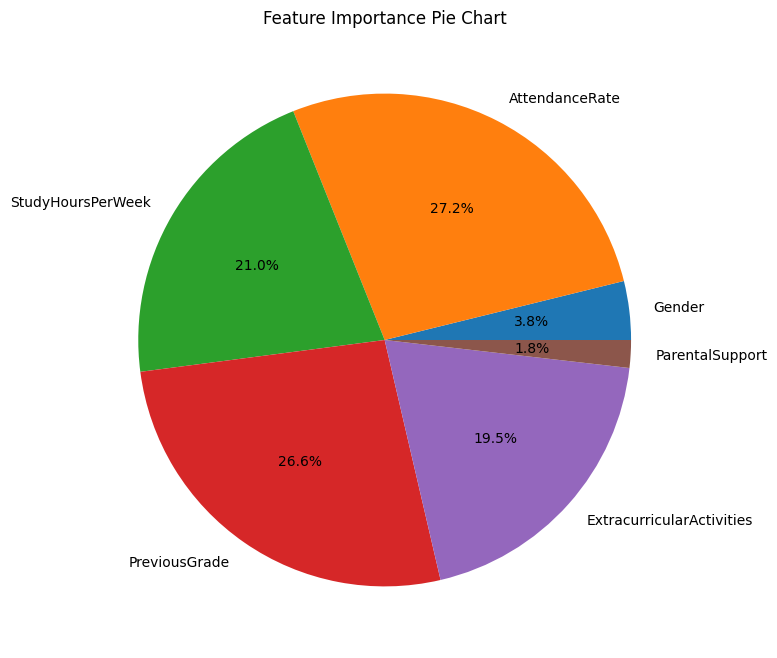

In [ ]:
importance = rf.feature_importances_

plt.figure(figsize=(8,8))
plt.pie(
    importance,
    labels=X.columns,
    autopct='%1.1f%%'
)

plt.title("Feature Importance Pie Chart")
plt.show()

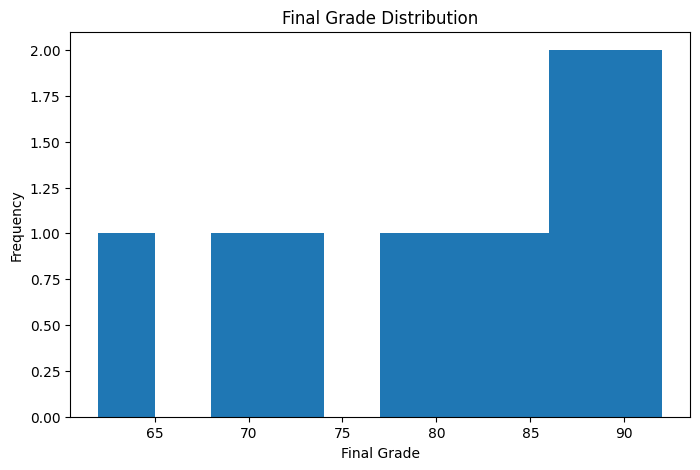

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df['FinalGrade'])
plt.title("Final Grade Distribution")
plt.xlabel("Final Grade")
plt.ylabel("Frequency")
plt.show()

In [ ]:
print(df.columns)

Index(['StudentID', 'Name', 'Gender', 'AttendanceRate', 'StudyHoursPerWeek',
       'PreviousGrade', 'ExtracurricularActivities', 'ParentalSupport',
       'FinalGrade'],
      dtype='object')


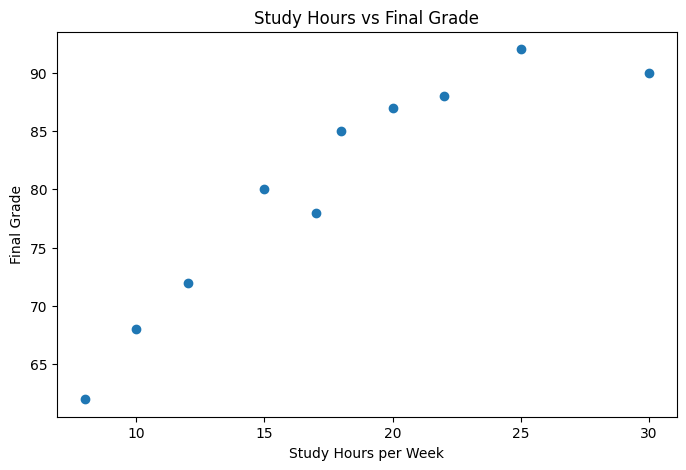

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df['StudyHoursPerWeek'], df['FinalGrade'])
plt.title("Study Hours vs Final Grade")
plt.xlabel("Study Hours per Week")
plt.ylabel("Final Grade")
plt.show()

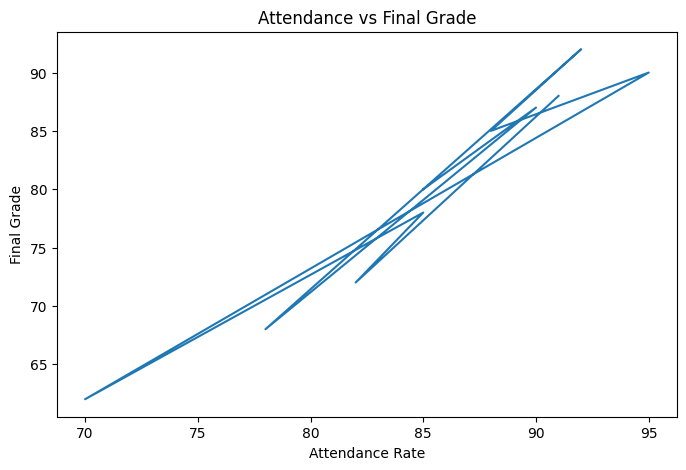

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(df['AttendanceRate'], df['FinalGrade'])
plt.title("Attendance vs Final Grade")
plt.xlabel("Attendance Rate")
plt.ylabel("Final Grade")
plt.show()

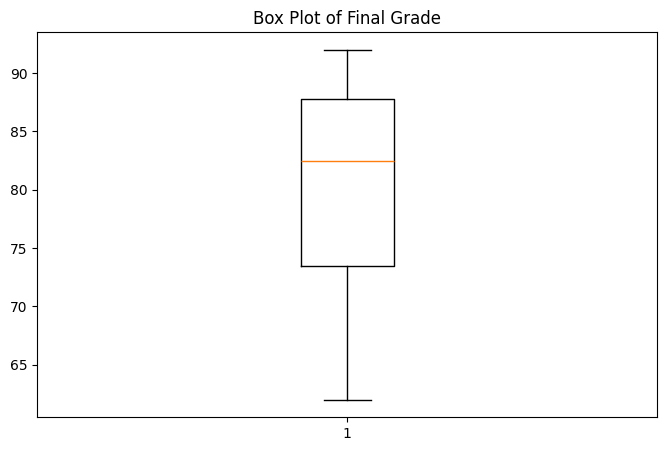

In [ ]:
plt.figure(figsize=(8,5))
plt.boxplot(df['FinalGrade'])
plt.title("Box Plot of Final Grade")
plt.show()

/tmp/ipykernel_3198/3915195751.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender', data=df, palette=['red','yellow']


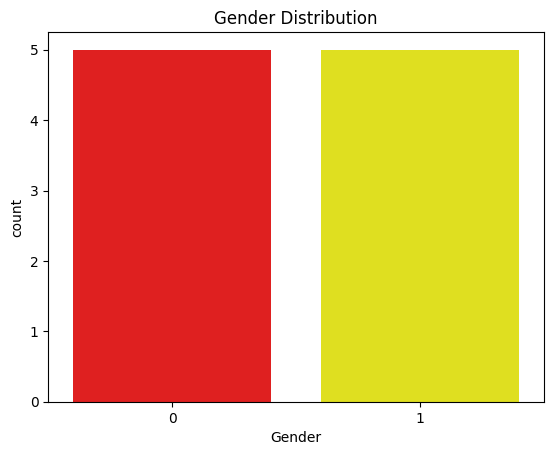

In [ ]:
sns.countplot(x='Gender', data=df, palette=['red','yellow']
)
plt.title("Gender Distribution")
plt.show()

<Figure size 500x300 with 0 Axes>

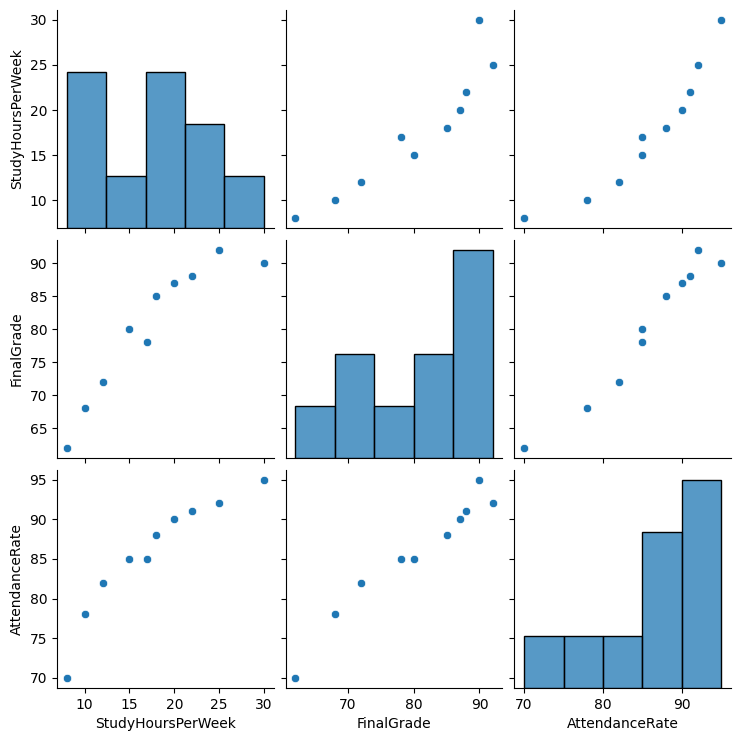

In [ ]:
plt.figure(figsize=(5,3))
sns.pairplot(
    df[['StudyHoursPerWeek', 'FinalGrade', 'AttendanceRate']]
)


plt.show()

In [ ]:
df_copy['Pass_Fail'] = df_copy['FinalGrade'].apply(lambda x: 1 if x >= 40 else 0)

In [ ]:
df_copy['Performance_Category'] = df_copy['FinalGrade'].apply(
    lambda x: 'Excellent' if x >= 85
    else 'Good' if x >= 70
    else 'Average' if x >= 50
    else 'Poor'
)

print(df_copy[['FinalGrade', 'Performance_Category']])

   FinalGrade Performance_Category
0          80                 Good
1          87            Excellent
2          68              Average
3          92            Excellent
4          85            Excellent
5          90            Excellent
6          62              Average
7          78                 Good
8          72                 Good
9          88            Excellent


In [ ]:
X2 = df_copy.drop(
    ['StudentID', 'Name', 'FinalGrade', 'Performance_Category'],
    axis=1
)

y2 = df_copy['Performance_Category']

print(X2.head())
print(y2.head())

   Gender  AttendanceRate  StudyHoursPerWeek  PreviousGrade  \
0       1              85                 15             78   
1       0              90                 20             85   
2       1              78                 10             65   
3       1              92                 25             90   
4       0              88                 18             82   

   ExtracurricularActivities  ParentalSupport  Pass_Fail  
0                          1                0          1  
1                          2                2          1  
2                          0                1          1  
3                          3                0          1  
4                          2                2          1  
0         Good
1    Excellent
2      Average
3    Excellent
4    Excellent
Name: Performance_Category, dtype: object


/tmp/ipykernel_3198/2793037382.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_copy, x='Performance_Category',


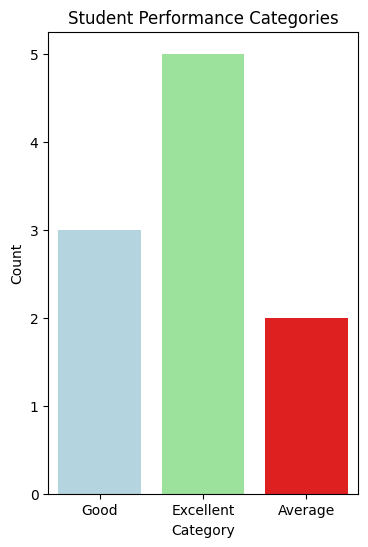

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(4,6))
sns.countplot(data=df_copy, x='Performance_Category',
palette=['lightblue', 'lightgreen', 'red']
)

plt.title("Student Performance Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

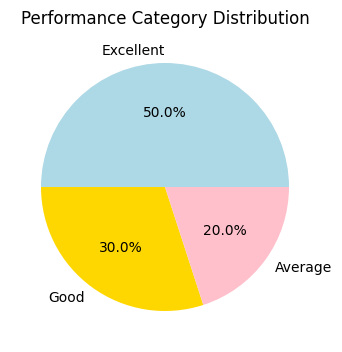

In [ ]:
category_counts = df_copy['Performance_Category'].value_counts()

plt.figure(figsize=(4,6))
plt.pie(
    category_counts,
    labels=category_counts.index,
    autopct='%1.1f%%',
    colors=['lightblue', 'gold', 'pink']

)

plt.title("Performance Category Distribution")
plt.show()

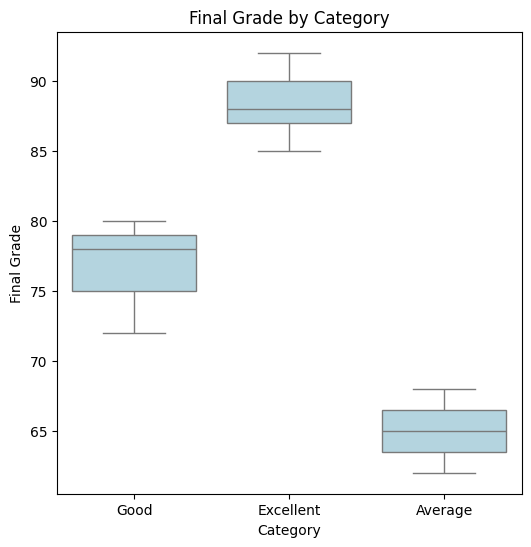

In [ ]:
plt.figure(figsize=(6,6))
sns.boxplot(
    data=df_copy,
    x='Performance_Category',
    y='FinalGrade',
    color='lightblue')

plt.title("Final Grade by Category")
plt.xlabel("Category")
plt.ylabel("Final Grade")
plt.show()

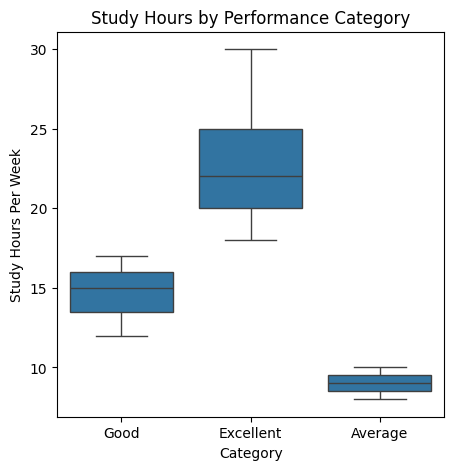

In [ ]:
plt.figure(figsize=(5,5))
sns.boxplot(
    data=df_copy,
    x='Performance_Category',
    y='StudyHoursPerWeek'
)

plt.title("Study Hours by Performance Category")
plt.xlabel("Category")
plt.ylabel("Study Hours Per Week")
plt.show()

In [ ]:
import pickle

pickle.dump(rf, open("model.pkl", "wb"))
print("Model saved successfully!")

Model saved successfully!


In [ ]:
print("AI-Based Student Performance Prediction System completed successfully.")
print("Model used: Random Forest Regressor")
print("Target predicted: FinalGrade")

AI-Based Student Performance Prediction System completed successfully.
Model used: Random Forest Regressor
Target predicted: FinalGrade
